# Продвинутый Python, Лекция 8

**Лектор:** Садуллаев Музаффар

**Семинаристы:** Бобоев Мурод, Богданов Сергей, Васина Олеся, Дергачев Cтепан, Какурин Василий, Садуллаев Музаффар, Солодовников Михаил

**In our heart**: Петров Тимур

**Spoiler Alert:** в рамках курса нельзя изучить ни одну из тем от и до досконально (к сожалению, на это требуется больше времени, чем даже 3 часа в неделю). Но мы попробуем рассказать столько, сколько возможно :)

# System Design

Сегодня будем делать интересную вещь -- поговорим про проектирование!!! На сегодня планируем спроектировать YouTube!

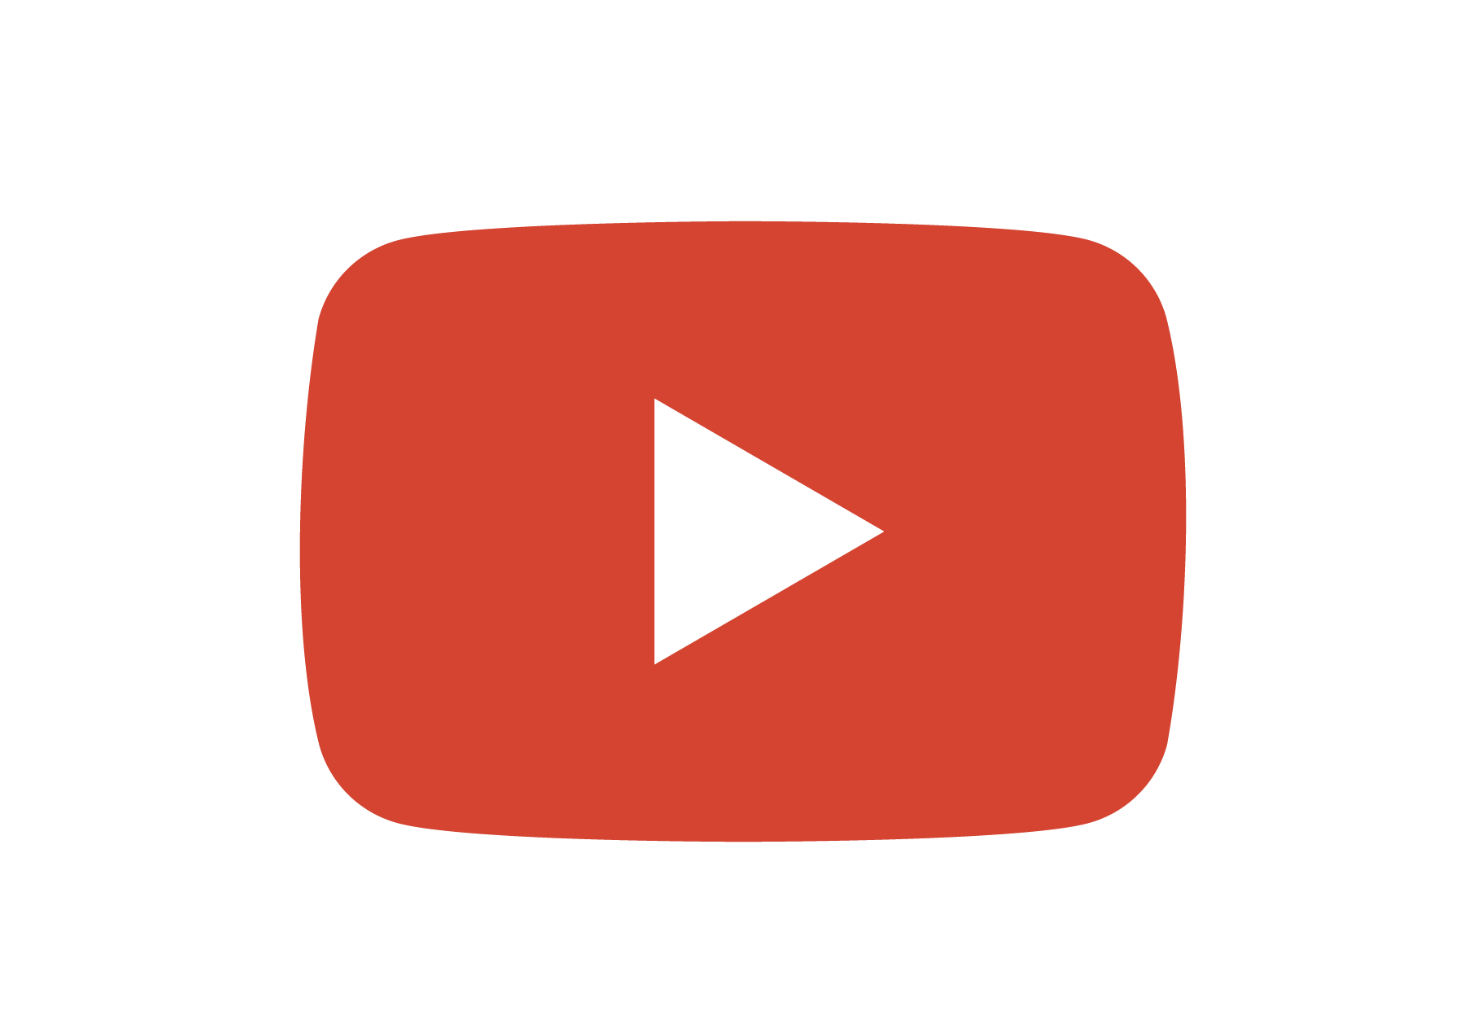

**Анекдот дня:**

— Зашёл на YouTube на пять минут посмотреть одно видео…


— И как?


— Теперь у меня три высших образования по кулинарии, ремонту стиралок и выращиванию авокадо, экспертиза в картах Таро.

### Вертикальное и горизонтальное масштабирование

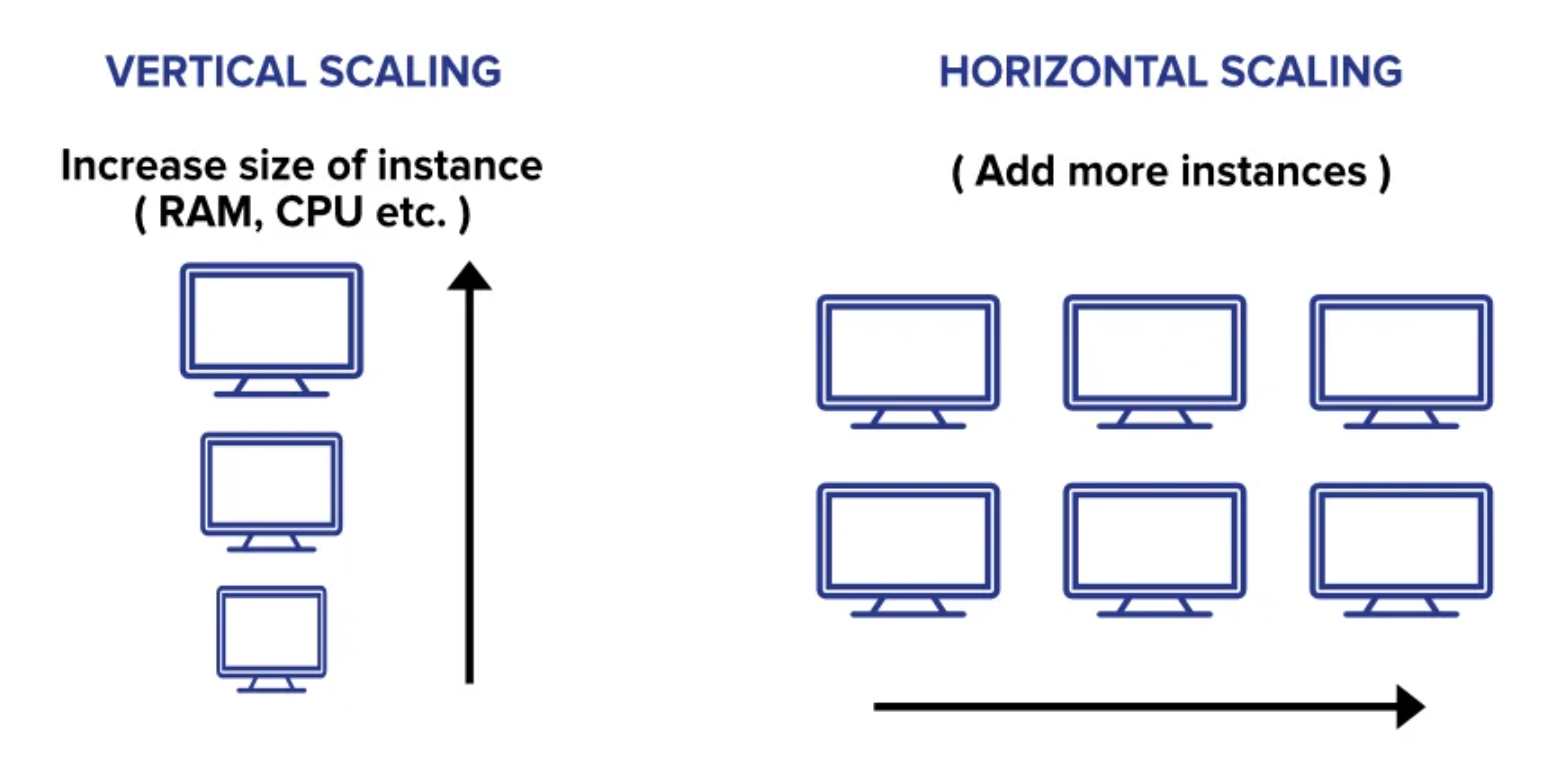

### Что делает YouTube как система?

* Загрузка видео

* Просмотр видео

* Комментарии, лайки

* Рекомендации

* Поиск

* Подписки

* Счётчик просмотров

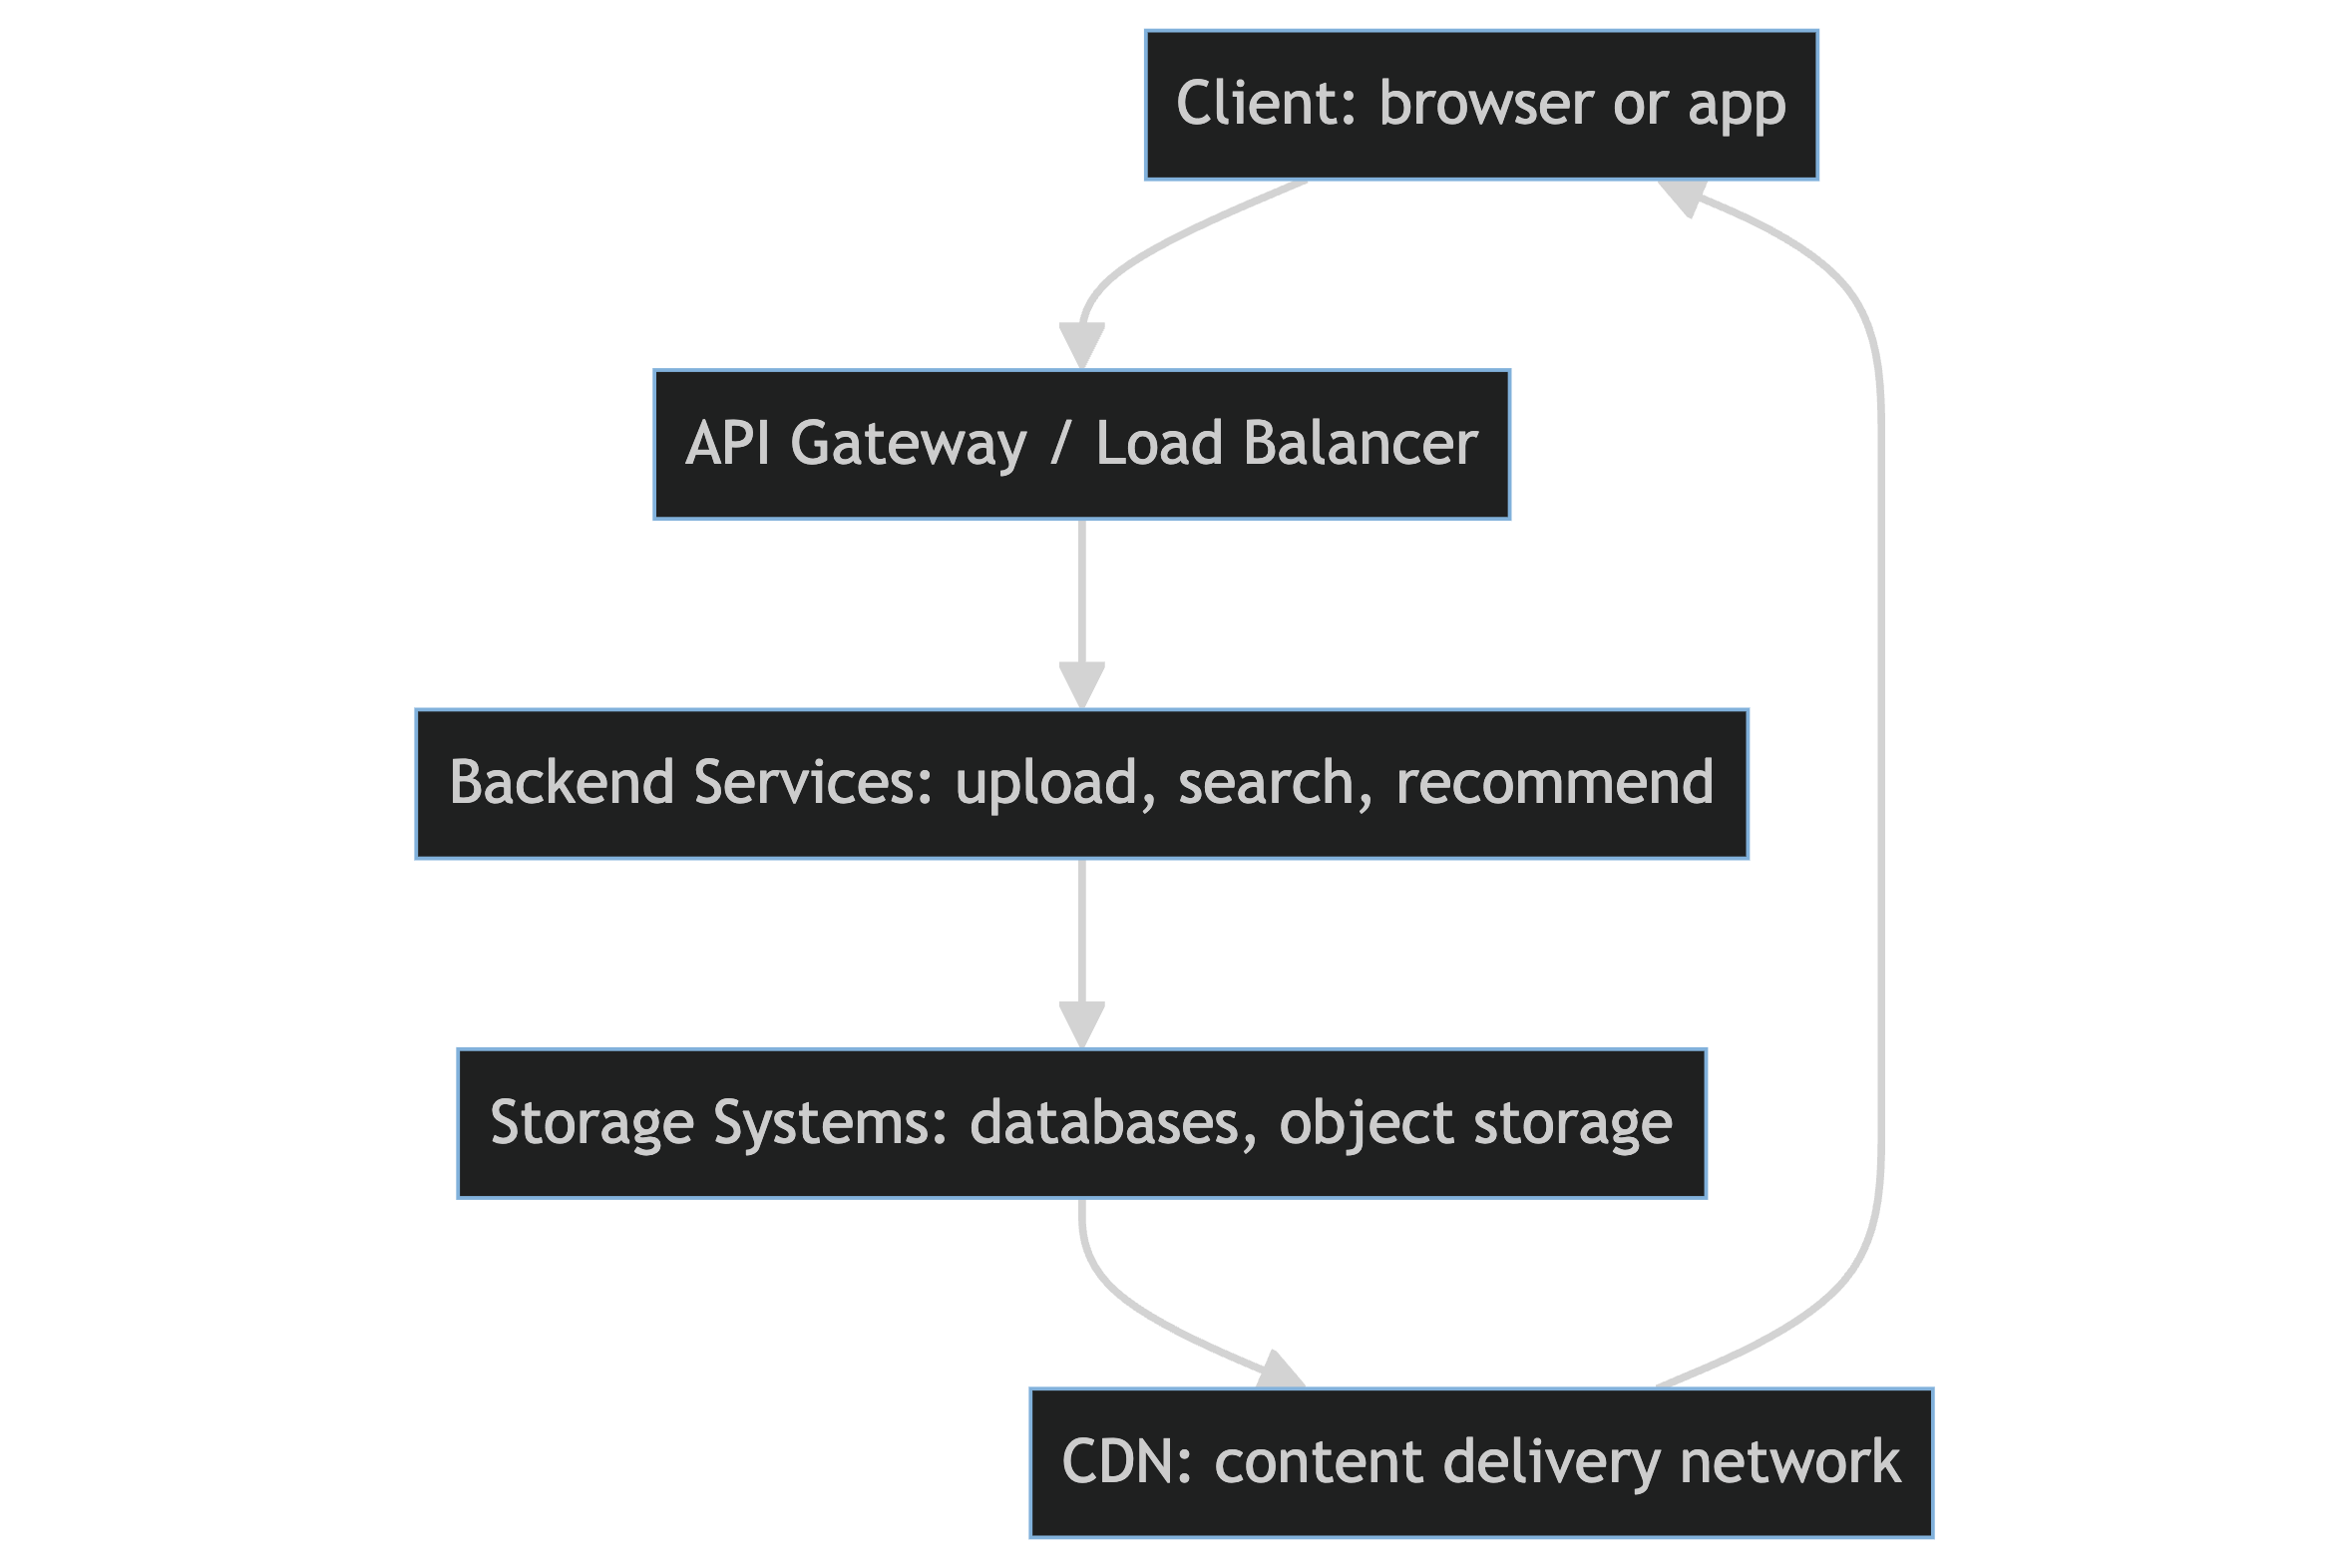

* API Gateway && LB — распределяет нагрузку.
* Backend Services — бизнес-логика: загрузка, поиск, рекомендации, пользователи
* Storage — база для метаданных + файлы видео
* CDN (Content Delivery Network) — ближайшие к пользователю сервера для быстрой доставки видео.

Представим, что вы решили загрузить видео на YouTube.

Что произойдет?!

### Загрузка во временное хранилище

Видео сначало идёт через API Gateway (или Load Balancer) — специальный "вход" в систему, который:
* распределяет нагрузку между множеством серверов
* проверяет авторизацию
* и направляет запрос в нужный сервис — Video Upload Service



Пока видео загружается, файл попадает во временное хранилище — например, в Amazon S3 или Google Cloud Storage.
Почему не сразу в основное?

Правильно! Для безопасности. А зачем?!
* видео может быть огромным
* пользователь может отменить загрузку
* нужно сначала проверить файл (на вирусы, формат, порнография, нацизм, фашизм, расизм, и прочие вещи)

### Фоновая обработка видео

Когда загрузка закончена, Video Processing Service берёт оригинальный файл и начинает его кушать:
* конвертирует (транскодирует) в разные форматы — 240p, 720p, 1080p, 4K
* создаёт превью и миниатюры
* извлекает длительность, разрешение и кодек



/* Здесь обычно задействуются очереди задач — чтобы тысячи видео обрабатывались параллельно, без перегрузки системы. */

### Публикация видео в хранилища

После обработки результаты отправляются:
* в Video Storage — это распределённое объектное хранилище, где лежат уже готовые файлы разных качеств;
* в CDN (Content Delivery Network) — чтобы зрителям по всему миру видео доставлялось быстро (из ближайшего дата-центра).



Параллельно система сохраняет метаданные видео:
* название, описание, теги, автор, длительность;
* статус (обрабатывается, готово, скрыто и т.д.);
* дата загрузки

## Итого:

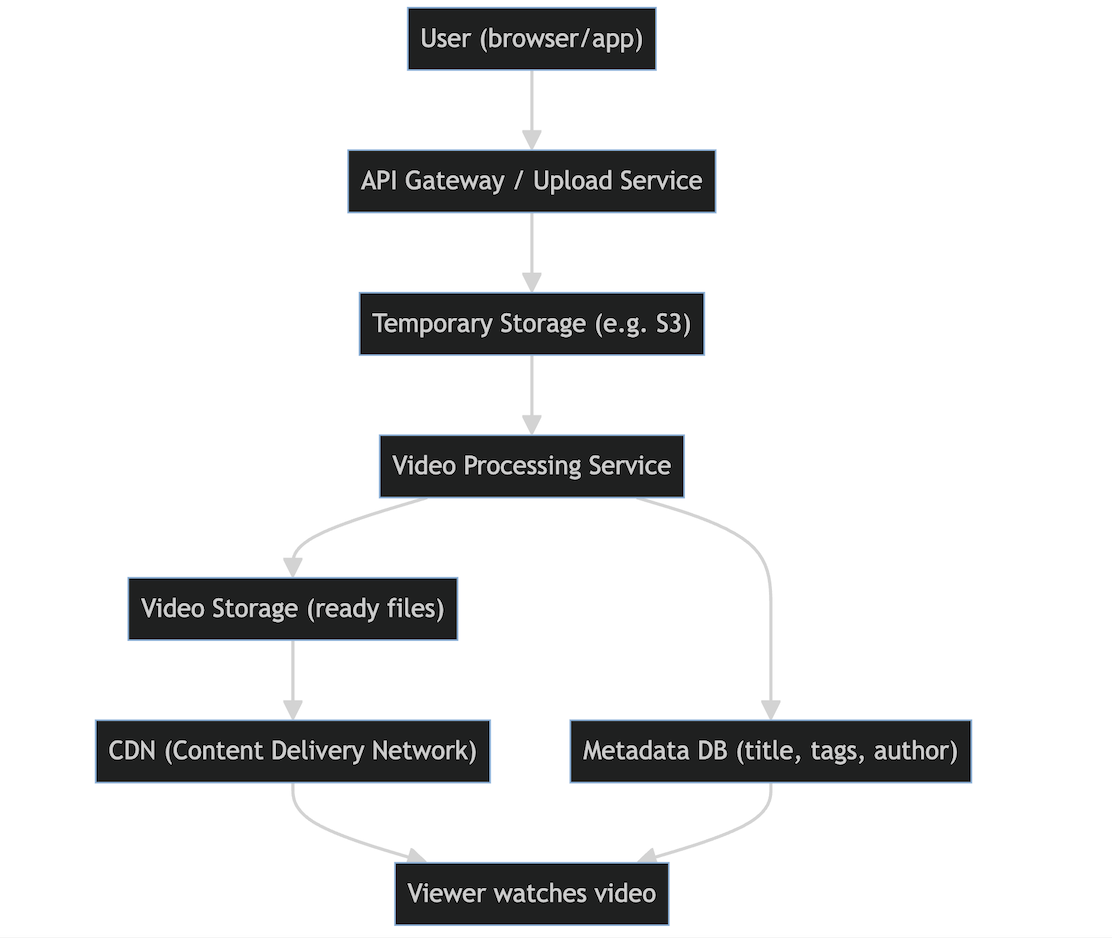

## Нужно спроектировать часть YouTube, которая позволяет пользователю загрузить видео, обработать его и потом показывать другим пользователям.

## Уточняем требования

* Пользователь может загружать видеофайлы.

* Видео автоматически обрабатывается (кодирование, генерация превью).

* Видео хранится и доступно для просмотра.

* Храним метаданные: название, описание, автор и т.д.

### Уточняем метрики
* Сколько людей пользуются системой? (dau)
* Сколько загрузок/просмотров в день? (uploads/days)
* Какой размер видео, сколько храним? (avg file sz)
* Насколько быстро? (latency)
* Как часто ошибки? (error perc)
* Как быстро растёт трафик/объём? (year-over-yaer)

### Какие метрики могут быть

| Метрика | Маленький проект | Средний проект | YouTube-уровень |
|----------|------------------|----------------|-----------------|
| **DAU** | 10 000 | 1 млн | 100 млн+ |
| **Uploads/day** | 500 | 100 000 | 5 млн |
| **Views/day** | 100 000 | 100 млн | 10 млрд |
| **Avg video size** | 200 МБ | 500 МБ | 500 МБ+ |
| **Read:Write ratio** | 10:1 | 100:1 | 1000:1 |
| **Latency target** | 1 с | 300 мс | < 200 мс |
| **Availability** | 95 % | 99 % | 99.9 % |

### Какие решения под каждый случай

| Компонент | Маленький проект | Средний проект | YouTube-уровень |
|------------|------------------|----------------|-----------------|
| **Хранение видео** | Локальная файловая система | Object Storage (S3, GCS) | Распределённое Object Storage (GFS / Colossus) |
| **Метаданные** | PostgreSQL | Шардированная SQL / NoSQL | Глобально распределённая NoSQL (Spanner, Cassandra) |
| **Обработка видео** | Синхронно в API | Асинхронно через очередь (RabbitMQ / SQS) | Масштабный Job Queue (Kafka, Pub/Sub) + Worker Pool |
| **Доставка видео** | С origin-сервера | CDN (CloudFront / Fastly) | Многоуровневая CDN с edge-серверами |
| **API Gateway** | Один сервер (Nginx) | Балансировщик + несколько API-нод | Глобальный load balancing + geo-routing |
| **Кеширование** | Не нужно или минимально | Redis для метаданных | Многоуровневый кеш (Redis + CDN edge cache) |
| **Мониторинг** | Логи вручную | Prometheus + Grafana | Полный observability stack |
| **Резервирование** | Периодический бэкап | Репликация | Multi-region failover и health checks |

## Примеры смены решений при росте метрик

### Загрузки в день

| Метрика | Решение | Причина |
|----------|----------|----------|
| 500 в день | Синхронная обработка в API | Нагрузка мала, API справляется |
| 5 млн в день | Асинхронная обработка (очереди, воркеры) | API перегружается, нужна масштабируемость |

### Средний размер файла

| Средний размер | Решение | Причина |
|----------------|----------|----------|
| < 50 МБ | Локальное хранилище | Просто и дёшево |
| ~ 500 МБ | Object Storage | Масштабируемо, отказоустойчиво |
| > 100 ТБ общих данных | Распределённая файловая система | Горизонтальное масштабирование, контроль размещения |

### Средний просмотр в день

| Просмотров в день | Решение | Причина |
|-------------------|----------|----------|
| < 100 тыс. | Отдача напрямую с origin | Малый трафик |
| 100 млн | CDN | Ускорение доставки |
| > 1 млрд | Многоуровневая CDN | Минимизация latency, баланс трафика по регионам |

### Паритет между чтением и записью (больше смотрят или больше загружают)

| Соотношение | Решение | Причина |
|--------------|----------|----------|
| 10:1 | Без кеша, обычная БД | Нагрузка умеренная |
| 100:1 | Redis / Memcached | Частые чтения, кеширование метаданных |
| 1000:1 | Многоуровневое кеширование | Edge-кеш, приложение, БД — оптимизация чтений |

### SLA

| Цель по доступности | Решение | Причина |
|----------------------|----------|----------|
| 95 % | Без репликации, простой деплой | MVP, допустимы простои |
| 99 % | Реплики в пределах региона | Устойчивость к падению сервера |
| 99.9 % | Multi-region, auto failover | Устойчивость к отказу дата-центра, SLA уровня YouTube |

## Подизайним средний проект

### Общая схема

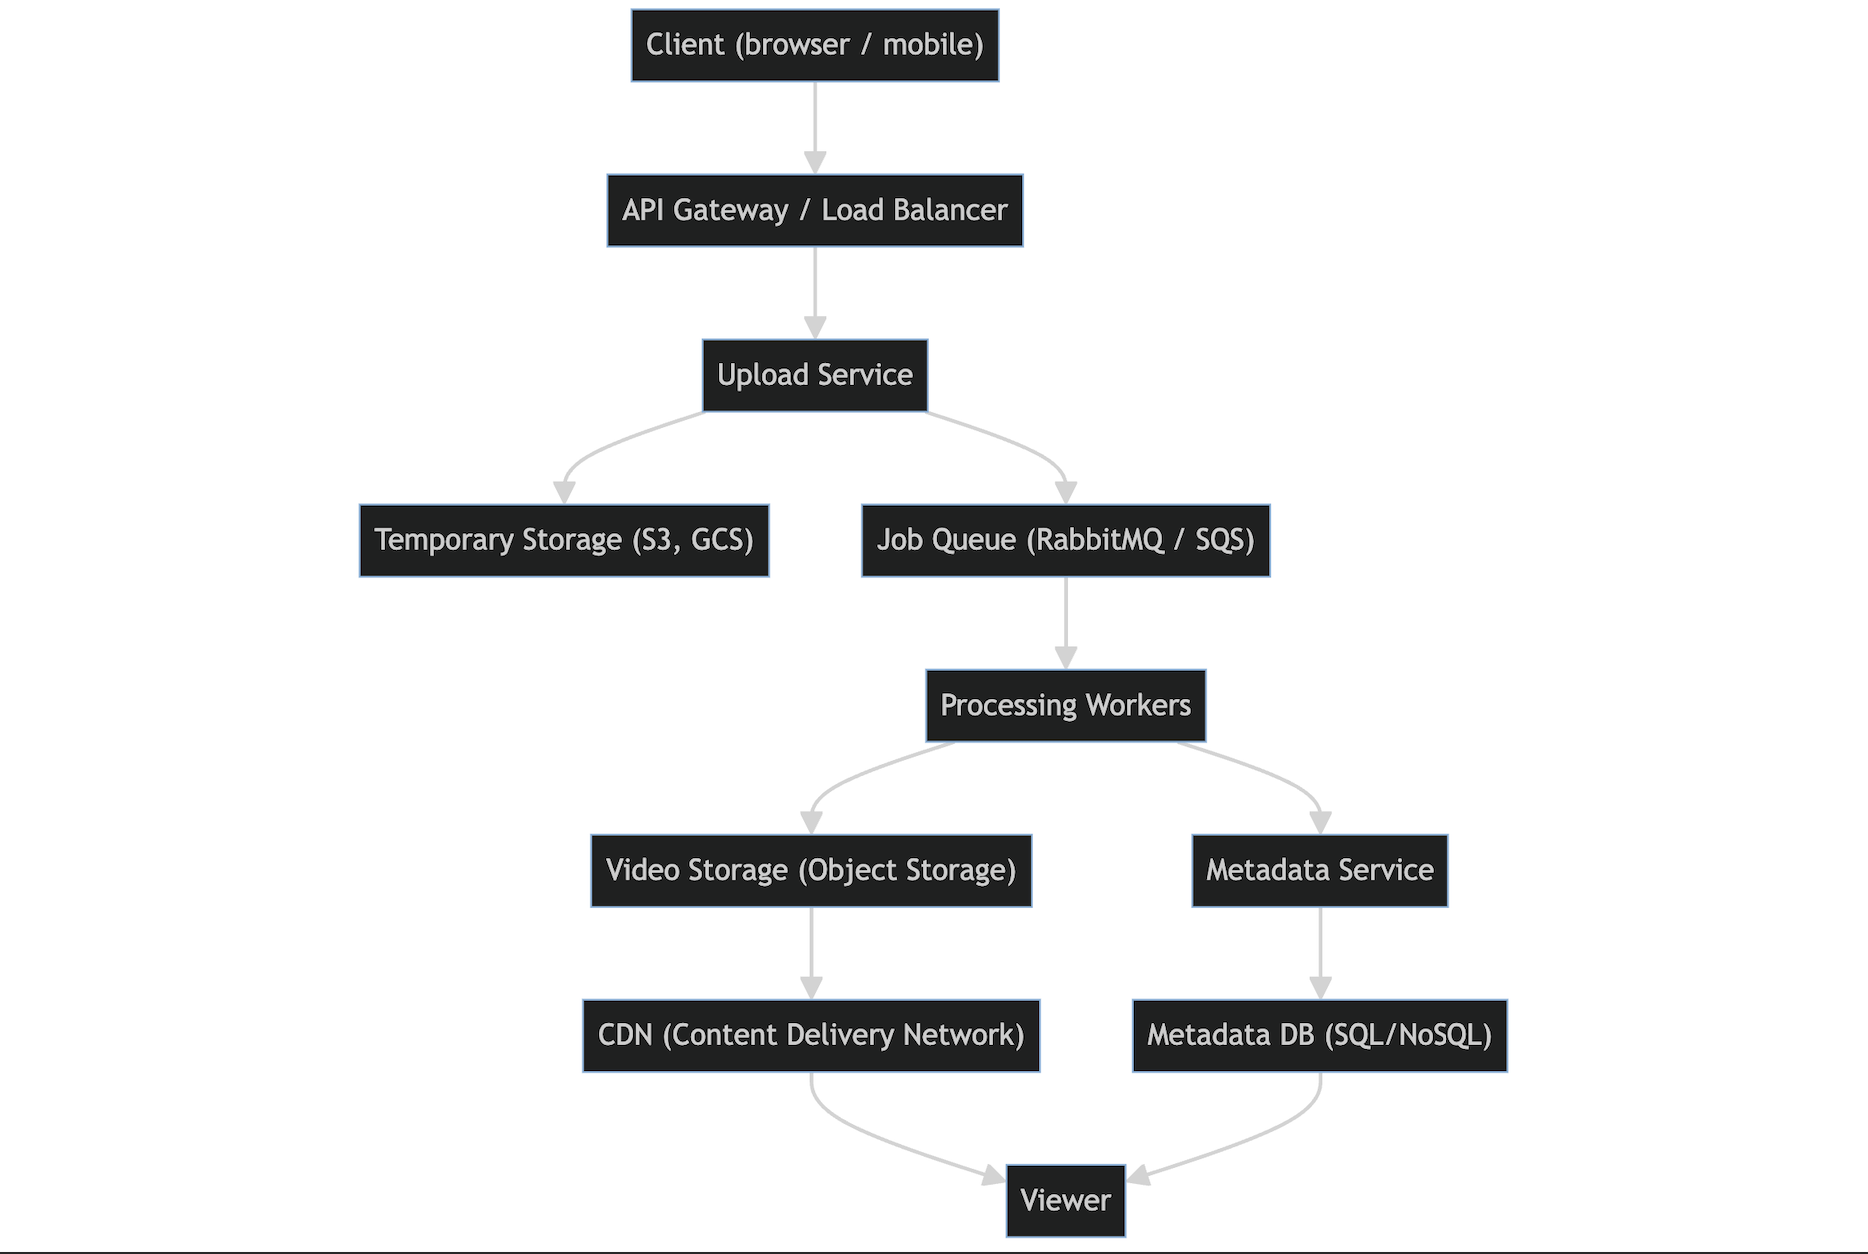

### Upload Service
* Принимает запрос от клиента (видео + метаданные)
* Сохраняет файл во временное хранилище
* Публикует задачу в очередь (например, AWS SQS или RabbitMQ)

### Processing Service (Worker Pool)
* Получает задачи из очереди
* Обрабатывает видео: 1) транскодирует в 240p, 720p, 1080p; 2) создаёт превью и обложку; 3) сохраняет готовые версии в Video Storage;
* Обновляет Metadata DB

!!!!При росте нагрузки — просто добавляем больше воркеров (горизонтальное масштабирование) !!!!

### CDN

Распределяет готовые видео по edge-серверам ближе к пользователю.

Ключевое: популярные видео ближе к зрителю!!!

Уменьшает latency и нагрузку на Video Storage.


а как это работает?

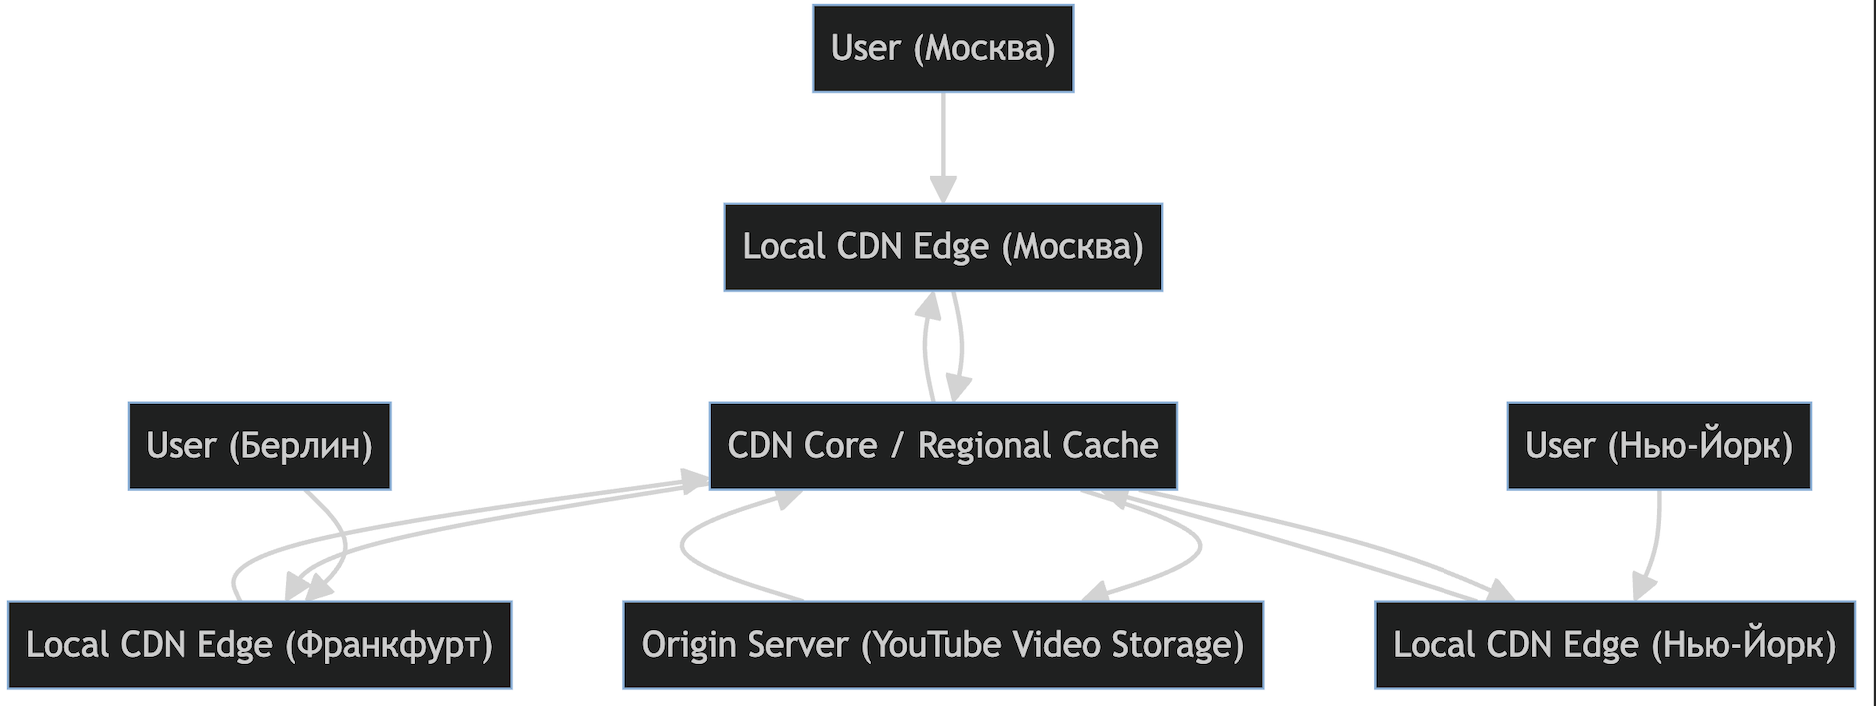

### DNS

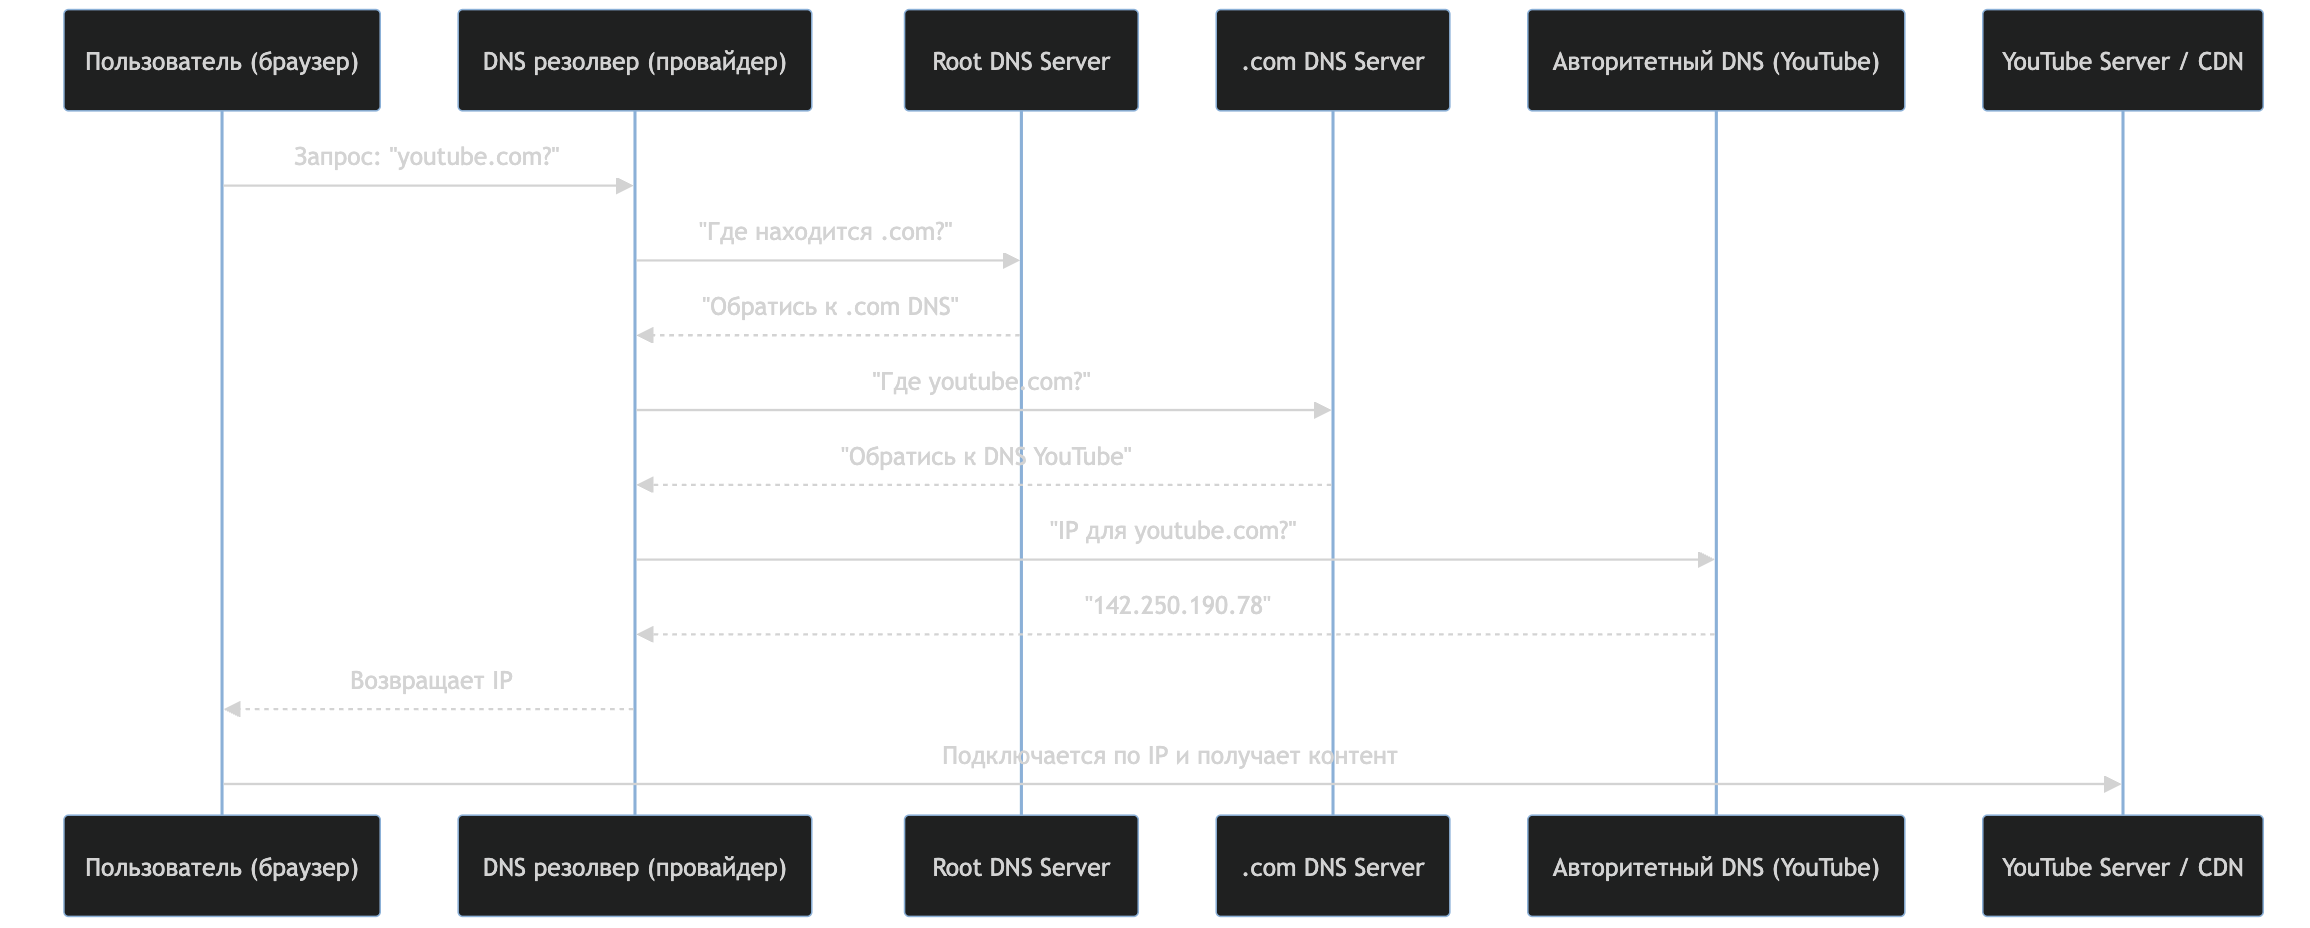


Пользователь открывает страницу с видео.

1) DNS решает, какой ближайший CDN-сервер использовать.

2) Браузер делает запрос туда.

3) Если видео есть в кеше → сразу отдаёт.

4) Если нет, CDN тянет оригинал из хранилища (origin), сохраняет копию.

Следующие пользователи получают контент мгновенно.

## Trade - off

| Компонент | Вариант 1 | Вариант 2 | Что выбрать для среднего уровня | Обоснование |
|------------|------------|------------|---------------------------------|--------------|
| **Хранение видео** | Локальное хранилище (диск сервера) | Object Storage (S3, GCS, MinIO) | Object Storage | Масштабируемо, дешево, высокая отказоустойчивость. Локальное хранилище подходит только для MVP. |
| **Метаданные** | SQL (PostgreSQL, MySQL) | NoSQL (Cassandra, DynamoDB) | SQL (с репликами) | Простая структура, транзакционность важна. NoSQL — избыточно для среднего масштаба. |
| **Очередь задач** | RabbitMQ / SQS | Kafka / Pub/Sub | RabbitMQ / SQS | Простая конфигурация, достаточно throughput. Kafka — для огромного потока событий (уровень YouTube). |
| **API Gateway** | Nginx | Envoy / Istio | Nginx или HAProxy | Простое масштабирование и балансировка. Service mesh пока избыточен. |
| **Кеш** | Redis | Memcached | Redis | Поддерживает структуры данных (счётчики, списки). Memcached — только key-value. |
| **Хранилище логов** | Локальные файлы | ELK Stack (Elastic, Logstash, Kibana) | ELK Stack | Централизованный сбор логов и визуализация метрик. |
| **Мониторинг** | Логи | Prometheus + Grafana | Prometheus + Grafana | Подходит для метрик API, очередей и воркеров. |
| **Доставка видео** | Origin-сервер | CDN (CloudFront / Fastly) | CDN | Уменьшает latency, снижает трафик с бэкенда. |
| **Балансировка нагрузки** | DNS Round Robin | Load Balancer (NGINX, AWS ALB) | Load Balancer | Управляет сессиями, health-check, маршрутизацией. |
| **База пользователей / авторизации** | Собственная реализация | Auth0 / Firebase Auth | Внешний сервис (Auth0, Firebase) | Снижает риск ошибок безопасности, упрощает разработку. |

